# 10 · 3작물 배분 최적화 (옥수수 · 대두 · 밀)

06은 2작물(옥수수/대두)로 풀었다. 04c에서 밀 모델을 만들었으니 **선택지를 3개로 늘려**
같은 문제를 다시 푼다.

## 06과 무엇이 같고 무엇이 다른가

| | 06 (2작물) | 10 (3작물) |
|---|---|---|
| 선택지 | 옥수수 / 대두 | 옥수수 / 대두 / **밀** |
| 공통 카운티 | 2,142 | **재계산** (밀 추가로 줄어든다) |
| 목적함수 | Σ A_c·v[c,z_c] − λ·전환면적 | **동일** |
| 순이익 | v = P·ŷ − C | **동일** (밀 가격·비용 추가) |
| 탐색 | GA(이진) | **GA·SA·TS (K작물판)** — `src/optimize_kcrop.py` |

문제 정의는 `CropAllocationProblem`(`src/optimize_ga.py`)을 **그대로 재사용**한다 —
이 클래스의 목적함수·정확해는 이미 K ≥ 2 를 지원한다. 이진 전용인 것은 GA/SA/TS의 **연산자**뿐이라,
K작물용 연산자를 담은 `optimize_kcrop.py` 를 새로 만들었다.

## 던지는 질문

1. **회복률이 오르는가?** 선택지가 늘면 최적해는 (약)개선되어야 한다 — 안 오르면 버그다.
2. **어디가 밀을 고르는가?** 밀이 실제로 선택되는 지역이 있는가.
3. **문제가 어려워져서 방법 간 차이가 나타나는가?** 06~09에서 GA·SA·TS는 전부 정확해에 도달했다.
   K=3 이면 탐색 공간이 2^2142 → 3^2056 으로 커진다. 그래도 여전히 쉬운가?

> 06·07·08·09의 원본과 산출물은 **건드리지 않는다.** 이 노트북은 읽기만 한다.

In [1]:
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from optimize_ga import CropAllocationProblem, find_knee
from optimize_kcrop import (run_ga_k, run_sa_k, run_ts_k, greedy_k,
                            random_baseline, sweep_lambda_k)

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CORN_C, SOY_C, WHEAT_C = '#eda100', '#1baf7a', '#a0522d'
GA_C, SA_C, TS_C, EX_C = BLUE, RED, GREEN, MUTED

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

# ── 경제 파라미터 ──────────────────────────────────────────────────────────
# 옥수수·대두는 06과 **완전히 동일한 값**. 밀만 추가 (USDA ERS 수준).
PRICE  = {'corn': 4.50,  'soybean': 10.50, 'wheat': 6.50}    # $/bu
OPCOST = {'corn': 400.0, 'soybean': 205.0, 'wheat': 175.0}   # $/ac
CROPS  = ['corn', 'soybean', 'wheat']          # 인덱스 0, 1, 2
CROP_KO = {'corn': '옥수수', 'soybean': '대두', 'wheat': '밀'}
CROP_COL = {'corn': CORN_C, 'soybean': SOY_C, 'wheat': WHEAT_C}
BASE, WARM = 'baseline', 'plus2C'
SEED = 42

print('가격  $/bu :', PRICE)
print('변동비 $/ac:', OPCOST)
print('  (옥수수·대두는 06과 동일. 밀은 USDA ERS 수준 — 한계 §8 참조)')

가격  $/bu : {'corn': 4.5, 'soybean': 10.5, 'wheat': 6.5}
변동비 $/ac: {'corn': 400.0, 'soybean': 205.0, 'wheat': 175.0}
  (옥수수·대두는 06과 동일. 밀은 USDA ERS 수준 — 한계 §8 참조)


## 1. 3작물 공통 카운티 — 교집합 재계산

세 작물 **모두** 재배 이력이 있어야 선택지가 셋인 문제가 성립한다.
밀이 들어오면서 공통 카운티가 줄어든다.

In [2]:
BUNDLE = {'corn':    joblib.load(PROC / 'yield_model_final.joblib'),
          'soybean': joblib.load(PROC / 'soybean_model_final.joblib'),
          'wheat':   joblib.load(PROC / 'wheat_model_final.joblib')}
FEATS = BUNDLE['corn']['features']
for k in CROPS:
    b = BUNDLE[k]
    assert list(b['features']) == FEATS, '%s 피처가 다르다' % k
    print('%-4s %-9s 전략 %s | CV R2 %.4f | RMSE %6.3f | %s'
          % (CROP_KO[k], b['model_name'], b['strategy'], b['cv_r2_mean'], b['cv_rmse_mean'],
             b.get('year_range', [1981, 2015])))
print('\n세 모델 피처셋 동일 (%d개) — 같은 X 행렬로 셋 다 예측 가능' % len(FEATS))

sc = pd.read_parquet(PROC / 'scenarios.parquet')
ct = {}
for k, f in [('corn', 'corn_panel.parquet'), ('soybean', 'soybean_panel.parquet'),
             ('wheat', 'wheat_panel.parquet')]:
    ct[k] = set(pd.read_parquet(PROC / f, columns=['stco']).stco.unique())
    print('%-4s 패널 카운티 %d' % (CROP_KO[k], len(ct[k])))

C2 = np.array(sorted(ct['corn'] & ct['soybean'] & set(sc.stco.unique())))          # 06의 2작물
C3 = np.array(sorted(ct['corn'] & ct['soybean'] & ct['wheat'] & set(sc.stco.unique())))
print()
print('2작물 공통 (06): %d 카운티' % len(C2))
print('3작물 공통 (10): %d 카운티   ← 밀 추가로 %d개 감소'
      % (len(C3), len(C2) - len(C3)))

COUNTIES = C3
N = len(COUNTIES)
A = sc.drop_duplicates('stco').set_index('stco')['A_c'].reindex(COUNTIES).to_numpy(float)
A_TOT = float(A.sum())
print('\n탐색 공간: 3^%d  (06은 2^%d)' % (N, len(C2)))
print('총 농지 %.3e ac' % A_TOT)

옥수수  LightGBM  전략 B | CV R2 0.7318 | RMSE 20.076 | [1981, 2015]
대두   LightGBM  전략 B | CV R2 0.8069 | RMSE  4.619 | [1981, 2015]
밀    LightGBM  전략 B | CV R2 0.6908 | RMSE  8.783 | [1981, 2007]

세 모델 피처셋 동일 (97개) — 같은 X 행렬로 셋 다 예측 가능
옥수수  패널 카운티 2644
대두   패널 카운티 2169
밀    패널 카운티 2674

2작물 공통 (06): 2142 카운티
3작물 공통 (10): 2056 카운티   ← 밀 추가로 86개 감소

탐색 공간: 3^2056  (06은 2^2142)
총 농지 1.554e+09 ac


## 2. 예측 수확량 · 순이익

시나리오별·작물별 예측. `year_fixed`(=2015) → `year` 매핑은 06과 동일.

> ⚠ **밀은 여기서 불리하다.** 밀 모델의 학습 범위는 2007까지라, `year = 2015` 를 넣어도
> 트리가 외삽하지 못해 **2007년 기술 수준**을 반환한다(04c §5에서 확인). 옥수수·대두는
> 2015년 기술로 예측된다. §7에서 이 편향에 대한 민감도를 확인한다.

In [3]:
y_hat, VAL = {}, {}
for s in [BASE, WARM]:
    d = sc[sc.scenario == s].set_index('stco').reindex(COUNTIES).copy()
    d['year'] = d['year_fixed']                       # 06과 동일한 매핑
    X = d[FEATS]
    assert X.notna().all().all()
    y_hat[s] = {k: BUNDLE[k]['model'].predict(X) for k in CROPS}
    VAL[s] = np.column_stack([PRICE[k] * y_hat[s][k] - OPCOST[k] for k in CROPS])   # (N,3)

rows = []
for s in [BASE, WARM]:
    for i, k in enumerate(CROPS):
        rows.append(dict(시나리오=s, 작물=CROP_KO[k],
                         y_hat_bu=np.average(y_hat[s][k], weights=A),
                         순이익_usd=np.average(VAL[s][:, i], weights=A)))
tbl = pd.DataFrame(rows)
print('면적가중 평균 (3작물 공통 카운티 %d개)' % N)
print(tbl.to_string(index=False, float_format='%.2f'))

print()
print('+2℃ 효과 (순이익 $/ac, 면적가중)')
for i, k in enumerate(CROPS):
    b = np.average(VAL[BASE][:, i], weights=A)
    w = np.average(VAL[WARM][:, i], weights=A)
    print('  %-4s %7.1f → %7.1f   (%+.1f, %+.1f%%)' % (CROP_KO[k], b, w, w - b, 100 * (w - b) / abs(b)))

print()
print('작물별 우위 카운티 수 (순이익 최대)')
for s in [BASE, WARM]:
    win = VAL[s].argmax(axis=1)
    print('  %-8s ' % s + ' · '.join('%s %d (%.1f%%)' % (CROP_KO[k], int((win == i).sum()),
                                                          100 * (win == i).mean())
                                      for i, k in enumerate(CROPS)))

면적가중 평균 (3작물 공통 카운티 2056개)
    시나리오  작물  y_hat_bu  순이익_usd
baseline 옥수수    137.72   219.73
baseline  대두     41.53   231.07
baseline   밀     49.18   144.68
  plus2C 옥수수    124.61   160.74
  plus2C  대두     37.30   186.64
  plus2C   밀     44.60   114.87

+2℃ 효과 (순이익 $/ac, 면적가중)
  옥수수    219.7 →   160.7   (-59.0, -26.9%)
  대두     231.1 →   186.6   (-44.4, -19.2%)
  밀      144.7 →   114.9   (-29.8, -20.6%)

작물별 우위 카운티 수 (순이익 최대)
  baseline 옥수수 793 (38.6%) · 대두 1146 (55.7%) · 밀 117 (5.7%)
  plus2C   옥수수 584 (28.4%) · 대두 1245 (60.6%) · 밀 227 (11.0%)


## 3. 현재 배분 x̄ — 3작물판

06과 **같은 규칙**을 3작물로 확장한다: 2011–2015년 관측 수확량에 순이익 규칙을 적용해
가장 높은 작물을 주작물로 본다. 결측 시 전체 기간 평균으로 대체.

> ⚠ **밀은 2007년까지만 관측된다.** 따라서 "최근 5년(2011–2015)" 규칙을 밀에 적용하면
> 무조건 결측이라 전체 기간 평균으로 대체된다. 즉 밀은 x̄ 산정에서도 구조적으로 불리하다.
> 이 점을 명시하고, 밀의 관측 기간(1981–2007) 평균을 쓴다.

In [4]:
yd = pd.read_csv(RAW / 'yielddata.csv')          # 읽기 전용
yd = yd[yd.stco.isin(COUNTIES)]

r5   = yd[yd.year.between(2011, 2015)].groupby('stco')[CROPS].mean()
rall = yd.groupby('stco')[CROPS].mean()
obs  = r5.reindex(COUNTIES).fillna(rall.reindex(COUNTIES))
print('최근 5년(2011-2015) 관측이 있는 카운티')
for k in CROPS:
    n5 = int(r5.reindex(COUNTIES)[k].notna().sum())
    print('  %-4s %4d / %d  %s' % (CROP_KO[k], n5, N,
                                   '← 밀은 2008년 이후 관측이 없어 0' if k == 'wheat' else ''))
assert obs.notna().all().all(), '관측 수확량 결측 잔존'

v_obs = np.column_stack([PRICE[k] * obs[k].to_numpy() - OPCOST[k] for k in CROPS])
XBAR = v_obs.argmax(axis=1).astype(np.int8)

print('\n현재 배분 x̄ (관측 순이익 기준)')
for i, k in enumerate(CROPS):
    m = XBAR == i
    print('  %-4s %4d 카운티 (%.1f%%)   면적 %.1f%%'
          % (CROP_KO[k], int(m.sum()), 100 * m.mean(), 100 * A[m].sum() / A_TOT))

최근 5년(2011-2015) 관측이 있는 카운티
  옥수수  1743 / 2056  
  대두   1655 / 2056  
  밀       0 / 2056  ← 밀은 2008년 이후 관측이 없어 0

현재 배분 x̄ (관측 순이익 기준)
  옥수수   769 카운티 (37.4%)   면적 46.4%
  대두   1044 카운티 (50.8%)   면적 46.5%
  밀     243 카운티 (11.8%)   면적 7.0%


## 4. 문제 정의 · 기준선

목적함수는 06과 완전히 동일하다. `CropAllocationProblem` 이 K작물을 그대로 지원한다.

In [5]:
prob      = CropAllocationProblem(value=VAL[WARM], area=A, baseline=XBAR)
prob_base = CropAllocationProblem(value=VAL[BASE], area=A, baseline=XBAR)
assert prob.n_crops == 3

V_BASE_NOADAPT = prob_base.total_value(XBAR)
V_WARM_NOADAPT = prob.total_value(XBAR)
LOSS = V_BASE_NOADAPT - V_WARM_NOADAPT

print('온난화 손실 기준선 (3작물 공통 카운티 %d개)' % N)
print('  baseline  총순이익 $%.4e' % V_BASE_NOADAPT)
print('  +2℃ 무조정        $%.4e' % V_WARM_NOADAPT)
print('  손실              $%.4e  (%.1f%%)' % (LOSS, 100 * LOSS / V_BASE_NOADAPT))

Z_GREEDY = greedy_k(prob)
print('\nGreedy (전환비용 무시)')
print('  회복률 %.2f%% · 전환 %d 카운티 · 전환면적 %.2f%%'
      % (prob.recovery_pct(Z_GREEDY, V_WARM_NOADAPT, LOSS),
         prob.n_switched(Z_GREEDY), 100 * prob.switch_area(Z_GREEDY) / A_TOT))
for i, k in enumerate(CROPS):
    print('    %-4s 면적 %.1f%%' % (CROP_KO[k], 100 * prob.crop_area(Z_GREEDY, i) / A_TOT))

rb = random_baseline(prob, 0.0, n=2000, seed=SEED)
print('\n무작위 배분 2,000개: 평균 $%.4e (std %.2e)' % (rb['mean'], rb['std']))

온난화 손실 기준선 (3작물 공통 카운티 2056개)
  baseline  총순이익 $3.7475e+11
  +2℃ 무조정        $2.9460e+11
  손실              $8.0158e+10  (21.4%)

Greedy (전환비용 무시)
  회복률 28.13% · 전환 863 카운티 · 전환면적 36.97%
    옥수수  면적 35.1%
    대두   면적 56.5%
    밀    면적 8.4%

무작위 배분 2,000개: 평균 $2.3943e+11 (std 2.53e+09)


## 5. λ 스윕 · 무릎 — 정확해로 곡선을 먼저 그린다

분리가능성은 K에 무관하게 성립하므로 `exact_optimum` 이 O(N·K) 에 정확해를 준다.
이것으로 트레이드오프 곡선과 무릎을 먼저 확정하고, 메타휴리스틱은 그 정확해로 채점한다.

In [6]:
LAMBDAS = np.concatenate([[0.0], np.geomspace(1.0, 400.0, 17)])
sw_ex = pd.DataFrame(sweep_lambda_k(prob, LAMBDAS, V_WARM_NOADAPT, LOSS, method='exact'))
sw_ex = sw_ex.sort_values('pct_area').reset_index(drop=True)

ki = find_knee(sw_ex.pct_area.to_numpy(), sw_ex.recovery_pct.to_numpy())
KNEE_LAM = float(sw_ex['lam'].to_numpy()[ki])
print('무릎: λ = %.4f $/ac · 전환면적 %.2f%% · 회복률 %.2f%%'
      % (KNEE_LAM, sw_ex.pct_area.iloc[ki], sw_ex.recovery_pct.iloc[ki]))
print('  (06의 2작물 무릎: λ = 42.29 · 면적 11.20% · 회복률 15.99%)')

Z_EXACT = prob.exact_optimum(KNEE_LAM)
F_EXACT = prob.fitness(Z_EXACT, KNEE_LAM)
print('\n정확해 F* = $%.6e  (메타휴리스틱 채점 기준)' % F_EXACT)

sw_ex_out = sw_ex.copy()
sw_ex_out[['corn_pct', 'soy_pct', 'wheat_pct']] = pd.DataFrame(
    sw_ex_out.crop_shares.tolist(), index=sw_ex_out.index)
sw_ex_out.drop(columns='crop_shares').to_csv(RES / 'tradeoff_3crop.csv', index=False)
print('saved:', RES / 'tradeoff_3crop.csv')

print('\nλ별 작물 면적 비율 (%)')
print(sw_ex_out[['lam', 'pct_area', 'recovery_pct', 'corn_pct', 'soy_pct', 'wheat_pct']]
      .sort_values('lam').iloc[::3].to_string(index=False, float_format='%.2f'))

무릎: λ = 42.2949 $/ac · 전환면적 13.09% · 회복률 19.12%
  (06의 2작물 무릎: λ = 42.29 · 면적 11.20% · 회복률 15.99%)

정확해 F* = $3.013168e+11  (메타휴리스틱 채점 기준)
saved: ..\outputs\results\tradeoff_3crop.csv

λ별 작물 면적 비율 (%)
   lam  pct_area  recovery_pct  corn_pct  soy_pct  wheat_pct
  0.00     36.97         28.13     35.10    56.51       8.39
  2.11     36.18         28.11     35.26    56.48       8.26
  6.50     33.25         27.87     35.66    56.13       8.21
 20.00     24.33         25.67     36.22    56.55       7.23
 61.51      8.30         14.43     40.52    51.98       7.49
189.15      0.19          0.73     46.27    46.64       7.08


## 6. GA · SA · TS (K작물) — 문제가 어려워졌는가?

06~09에서 세 방법은 2작물 문제에서 **전부 정확해에 도달**했다(분리 가능해서).
K=3 이면 탐색 공간이 3^2056 으로 커진다. **그래도 여전히 쉬운가?**

In [7]:
GA_POP, GA_GEN = 200, 800
BUDGET = GA_POP * (GA_GEN + 1)

runs = {
    'GA': run_ga_k(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED),
    'SA': run_sa_k(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=200, alpha=0.95,
                   target_accept=0.8, seed=SEED),
    'TS': run_ts_k(prob, KNEE_LAM, n_iter=1000, tabu_tenure=20, seed=SEED),
}

rows = []
for nm, r in runs.items():
    z = r['best']
    rows.append(dict(방법=nm, 적합도=r['best_fit'],
                     갭_pct=100 * (F_EXACT - r['best_fit']) / abs(F_EXACT),
                     정확해일치_pct=100 * (z == Z_EXACT).mean(),
                     평가횟수=r['n_eval'], 초=r['seconds']))
single3 = pd.DataFrame(rows)
print('3작물 — GA vs SA vs TS (λ = %.1f)' % KNEE_LAM)
print(single3.to_string(index=False, float_format='%.6g'))
print('\n정확해 F* = $%.6e' % F_EXACT)

3작물 — GA vs SA vs TS (λ = 42.3)
방법         적합도     갭_pct  정확해일치_pct    평가횟수        초
GA 3.01283e+11 0.0111668     98.249  160200  9.07948
SA 3.01317e+11         0        100  160200  1.11125
TS 3.01317e+11         0        100 4112000 0.165472

정확해 F* = $3.013168e+11


In [8]:
# 안정성 — 10 seed
N_SEEDS = 10
rows = []
for nm, fn in [('GA', lambda s: run_ga_k(prob, KNEE_LAM, pop_size=GA_POP,
                                         n_generations=GA_GEN, seed=s)),
               ('SA', lambda s: run_sa_k(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=200,
                                         alpha=0.95, target_accept=0.8, seed=s)),
               ('TS', lambda s: run_ts_k(prob, KNEE_LAM, n_iter=1000, tabu_tenure=20, seed=s))]:
    for s in range(N_SEEDS):
        r = fn(s)
        rows.append(dict(method=nm, seed=s, fitness=r['best_fit'],
                         gap_pct=100 * (F_EXACT - r['best_fit']) / abs(F_EXACT),
                         agree_pct=100 * (r['best'] == Z_EXACT).mean(),
                         recovery_pct=prob.recovery_pct(r['best'], V_WARM_NOADAPT, LOSS),
                         seconds=r['seconds']))
stab3 = pd.DataFrame(rows)
stab3.to_csv(RES / 'stability_3crop.csv', index=False)

summ3 = stab3.groupby('method', sort=False).agg(
    갭평균_pct=('gap_pct', 'mean'), 갭최악_pct=('gap_pct', 'max'),
    적합도_표준편차=('fitness', 'std'), 정확해일치_pct=('agree_pct', 'mean'),
    회복률_평균=('recovery_pct', 'mean'), 회복률_표준편차=('recovery_pct', 'std'),
    시간_평균초=('seconds', 'mean'),
).reset_index()
print('3작물 안정성 (%d seed)' % N_SEEDS)
print(summ3.to_string(index=False, float_format='%.5g'))
print('\nsaved:', RES / 'stability_3crop.csv')
print()
print()
if summ3.갭최악_pct.max() < 1e-9:
    print('→ 셋 다 정확해에 도달. K=3 으로 늘려도 여전히 쉽다.')
else:
    print('→ 06~09에서 처음으로 **방법 간 차이**가 나타났다.')
    print('   최악 갭: %s' % summ3.set_index('method').갭최악_pct.round(6).to_dict())
    print()
    print('   ⚠ 단, 이것을 "K=3 이라 문제가 어려워졌다"로 읽으면 틀린다.')
    print('     문제는 여전히 **분리 가능**하고(카운티 간 항이 없다), 정확해는 O(N·K) 에 나온다.')
    print('     실제로 TS 는 10개 seed 전부에서 정확해에 100%% 도달했다(분산 0).')
    print('     달라진 것은 **GA 의 연산자**다. 이진의 bit-flip 은 "뒤집기" 한 가지지만,')
    print('     K작물의 random-reset 은 K-1 개 중 하나를 무작위로 고르므로 탐색이 묽어진다.')
    print('     → "문제가 어려워졌다"가 아니라 "GA 가 K작물에서 약해졌다"가 정확한 서술이다.')

3작물 안정성 (10 seed)
method    갭평균_pct    갭최악_pct   적합도_표준편차  정확해일치_pct  회복률_평균  회복률_표준편차  시간_평균초
    GA    0.01037   0.016151 8.8122e+06     98.346  18.743  0.083695   8.182
    SA 3.2452e-06 2.0587e-05      19275     99.981  19.129  0.028267  1.0555
    TS          0          0          0        100  19.117         0 0.17995

saved: ..\outputs\results\stability_3crop.csv


→ 06~09에서 처음으로 **방법 간 차이**가 나타났다.
   최악 갭: {'GA': 0.016151, 'SA': 2.1e-05, 'TS': 0.0}

   ⚠ 단, 이것을 "K=3 이라 문제가 어려워졌다"로 읽으면 틀린다.
     문제는 여전히 **분리 가능**하고(카운티 간 항이 없다), 정확해는 O(N·K) 에 나온다.
     실제로 TS 는 10개 seed 전부에서 정확해에 100%% 도달했다(분산 0).
     달라진 것은 **GA 의 연산자**다. 이진의 bit-flip 은 "뒤집기" 한 가지지만,
     K작물의 random-reset 은 K-1 개 중 하나를 무작위로 고르므로 탐색이 묽어진다.
     → "문제가 어려워졌다"가 아니라 "GA 가 K작물에서 약해졌다"가 정확한 서술이다.


### 그림 1 — 3작물 수렴 곡선

saved: ..\outputs\figures\fig43_3crop_convergence.png


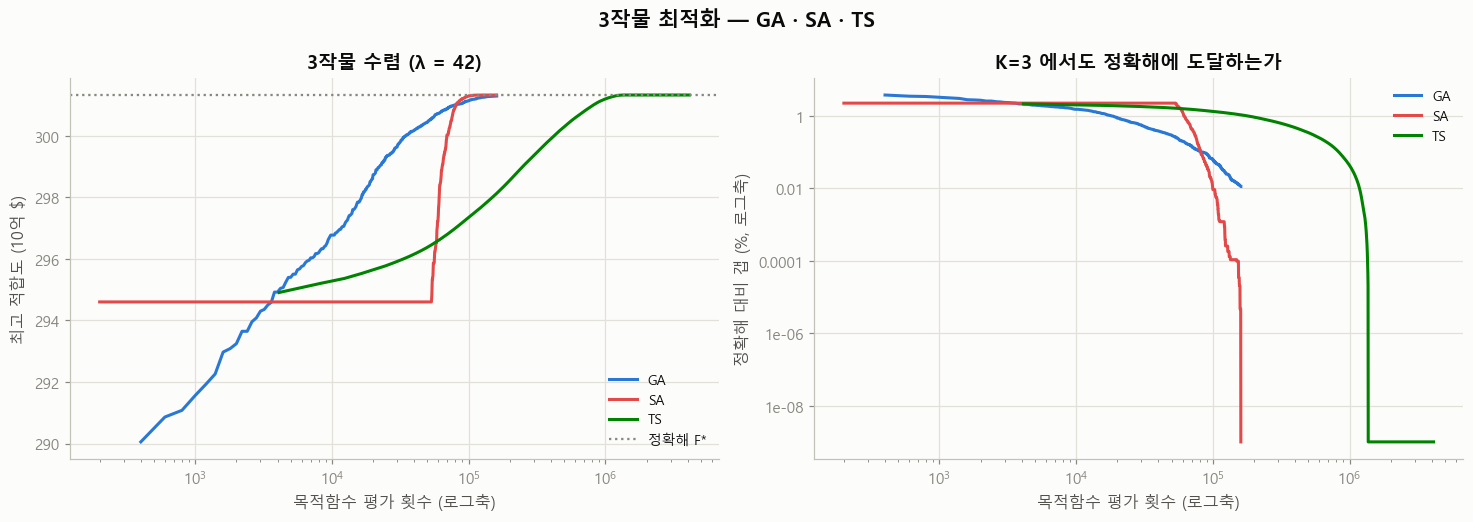

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ga_evals = np.arange(1, GA_GEN + 1) * GA_POP + GA_POP
ax = axes[0]
ax.plot(ga_evals, runs['GA']['history'] / 1e9, color=GA_C, lw=2, label='GA')
ax.plot(runs['SA']['hist_evals'], runs['SA']['history'] / 1e9, color=SA_C, lw=2, label='SA')
ax.plot(runs['TS']['hist_evals'], runs['TS']['history'] / 1e9, color=TS_C, lw=2, label='TS')
ax.axhline(F_EXACT / 1e9, color=EX_C, ls=':', lw=1.5, label='정확해 F*')
ax.set_xscale('log')
ax.set_xlabel('목적함수 평가 횟수 (로그축)')
ax.set_ylabel('최고 적합도 (10억 $)')
ax.set_title('3작물 수렴 (λ = %.0f)' % KNEE_LAM)
ax.legend(frameon=False, fontsize=9, loc='lower right')

ax = axes[1]
for nm, ev, col in [('GA', ga_evals, GA_C),
                    ('SA', runs['SA']['hist_evals'], SA_C),
                    ('TS', runs['TS']['hist_evals'], TS_C)]:
    gap = 100 * (F_EXACT - runs[nm]['history']) / abs(F_EXACT)
    ax.plot(ev, np.maximum(gap, 1e-9), color=col, lw=2, label=nm)
ax.set_xscale('log'); ax.set_yscale('log')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
ax.set_xlabel('목적함수 평가 횟수 (로그축)')
ax.set_ylabel('정확해 대비 갭 (%, 로그축)')
ax.set_title('K=3 에서도 정확해에 도달하는가')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('3작물 최적화 — GA · SA · TS', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig43_3crop_convergence.png'); plt.show()

## 7. 2작물 vs 3작물 — 선택지를 늘리면 무엇이 달라지는가

**공정 비교의 함정:** 06은 2,142개 카운티, 10은 그보다 적다. 카운티 집합이 다르면 회복률을
직접 비교할 수 없다. 그래서 **3작물 공통 카운티(같은 집합) 위에서** 2작물 문제를 다시 풀어
비교한다.

In [10]:
# 같은 카운티 집합에서 2작물 문제 (밀 선택지만 제거)
VAL2_WARM = VAL[WARM][:, :2]                       # 옥수수·대두만
VAL2_BASE = VAL[BASE][:, :2]
# x̄ 도 2작물 규칙으로 다시 (밀을 고른 카운티는 옥수수/대두 중 관측 순이익 높은 쪽)
XBAR2 = v_obs[:, :2].argmax(axis=1).astype(np.int8)

prob2      = CropAllocationProblem(VAL2_WARM, A, XBAR2)
prob2_base = CropAllocationProblem(VAL2_BASE, A, XBAR2)
V2_NOADAPT = prob2.total_value(XBAR2)
LOSS2 = prob2_base.total_value(XBAR2) - V2_NOADAPT

sw2 = pd.DataFrame(sweep_lambda_k(prob2, LAMBDAS, V2_NOADAPT, LOSS2, method='exact'))
sw2 = sw2.sort_values('pct_area').reset_index(drop=True)
ki2 = find_knee(sw2.pct_area.to_numpy(), sw2.recovery_pct.to_numpy())
KNEE2 = float(sw2['lam'].to_numpy()[ki2])
Z2 = prob2.exact_optimum(KNEE2)

print('같은 %d개 카운티에서 2작물 vs 3작물 (각자의 무릎에서)' % N)
rows = [
    dict(문제='2작물 (옥수수·대두)', 무릎λ=KNEE2,
         회복률_pct=prob2.recovery_pct(Z2, V2_NOADAPT, LOSS2),
         전환_카운티=prob2.n_switched(Z2),
         전환면적_pct=100 * prob2.switch_area(Z2) / A_TOT,
         온난화손실=LOSS2),
    dict(문제='3작물 (+ 밀)', 무릎λ=KNEE_LAM,
         회복률_pct=prob.recovery_pct(Z_EXACT, V_WARM_NOADAPT, LOSS),
         전환_카운티=prob.n_switched(Z_EXACT),
         전환면적_pct=100 * prob.switch_area(Z_EXACT) / A_TOT,
         온난화손실=LOSS),
]
cmp23 = pd.DataFrame(rows)
print(cmp23.to_string(index=False, float_format='%.4g'))
cmp23.to_csv(RES / 'compare_2crop_vs_3crop.csv', index=False)

# 밀이 실제로 선택되는가
n_wheat = int((Z_EXACT == 2).sum())
print()
print('3작물 최적해에서 밀을 고른 카운티: %d / %d (%.1f%%) · 면적 %.2f%%'
      % (n_wheat, N, 100 * n_wheat / N, 100 * prob.crop_area(Z_EXACT, 2) / A_TOT))
if n_wheat == 0:
    print('  → 밀이 전혀 선택되지 않는다. 선택지를 늘려도 답이 안 바뀐다.')
else:
    print('  → 밀이 선택된다. 어느 지역인지 §8 지도 참조.')

print('\n작물별 면적 비율')
print('  %-14s ' % '현재 x̄' + ' · '.join('%s %.1f%%' % (CROP_KO[k], 100 * A[XBAR == i].sum() / A_TOT)
                                         for i, k in enumerate(CROPS)))
print('  %-14s ' % '3작물 최적해' + ' · '.join('%s %.1f%%' % (CROP_KO[k], 100 * prob.crop_area(Z_EXACT, i) / A_TOT)
                                              for i, k in enumerate(CROPS)))

같은 2056개 카운티에서 2작물 vs 3작물 (각자의 무릎에서)
          문제   무릎λ  회복률_pct  전환_카운티  전환면적_pct     온난화손실
2작물 (옥수수·대두) 42.29    15.99     233     11.31 8.509e+10
   3작물 (+ 밀) 42.29    19.12     333     13.09 8.016e+10

3작물 최적해에서 밀을 고른 카운티: 213 / 2056 (10.4%) · 면적 7.64%
  → 밀이 선택된다. 어느 지역인지 §8 지도 참조.

작물별 면적 비율
  현재 x̄          옥수수 46.4% · 대두 46.5% · 밀 7.0%
  3작물 최적해        옥수수 38.5% · 대두 53.8% · 밀 7.6%


### 그림 2 — 2작물 vs 3작물 트레이드오프

saved: ..\outputs\figures\fig44_2crop_vs_3crop.png


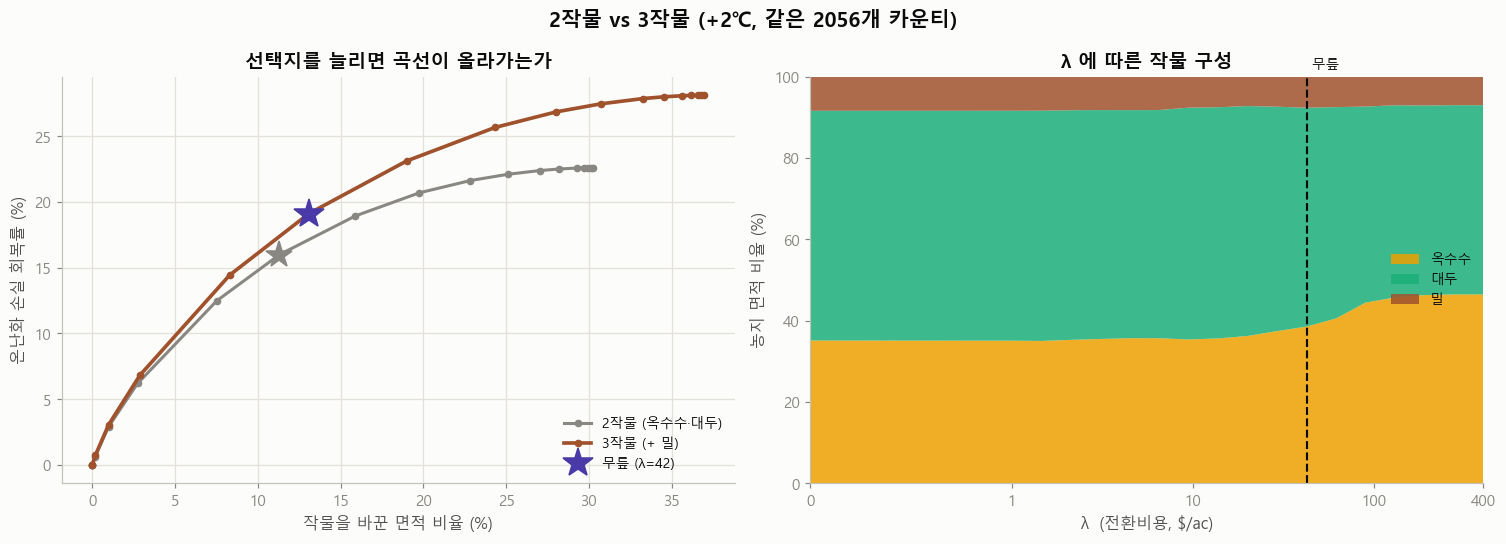

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0))

ax = axes[0]
ax.plot(sw2.pct_area, sw2.recovery_pct, '-o', color=MUTED, ms=4, lw=2,
        label='2작물 (옥수수·대두)')
ax.plot(sw_ex.pct_area, sw_ex.recovery_pct, '-o', color=WHEAT_C, ms=4, lw=2.4,
        label='3작물 (+ 밀)')
ax.plot(sw2.pct_area.iloc[ki2], sw2.recovery_pct.iloc[ki2], '*', color=MUTED, ms=18)
ax.plot(sw_ex.pct_area.iloc[ki], sw_ex.recovery_pct.iloc[ki], '*', color=VIOLET, ms=20,
        label='무릎 (λ=%.0f)' % KNEE_LAM)
ax.set_xlabel('작물을 바꾼 면적 비율 (%)')
ax.set_ylabel('온난화 손실 회복률 (%)')
ax.set_title('선택지를 늘리면 곡선이 올라가는가')
ax.legend(frameon=False, fontsize=9, loc='lower right')

ax = axes[1]
so = sw_ex_out.sort_values('lam')
ax.stackplot(so.lam, so.corn_pct, so.soy_pct, so.wheat_pct,
             colors=[CORN_C, SOY_C, WHEAT_C], labels=['옥수수', '대두', '밀'], alpha=0.85)
ax.axvline(KNEE_LAM, color=INK, ls='--', lw=1.4)
ax.text(KNEE_LAM, 102, ' 무릎', fontsize=9, color=INK)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(0, 400); ax.set_ylim(0, 100)
ax.set_xticks([0, 1, 10, 100, 400]); ax.set_xticklabels(['0', '1', '10', '100', '400'])
ax.set_xlabel('λ  (전환비용, $/ac)')
ax.set_ylabel('농지 면적 비율 (%)')
ax.set_title('λ 에 따른 작물 구성')
ax.legend(frameon=False, fontsize=9, loc='center right')
ax.grid(False)

fig.suptitle('2작물 vs 3작물 (+2℃, 같은 %d개 카운티)' % N,
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig44_2crop_vs_3crop.png'); plt.show()

## 8. 작물 배치 지도 — 어디가 밀을 고르는가

saved: ..\outputs\figures\fig45_3crop_map.png


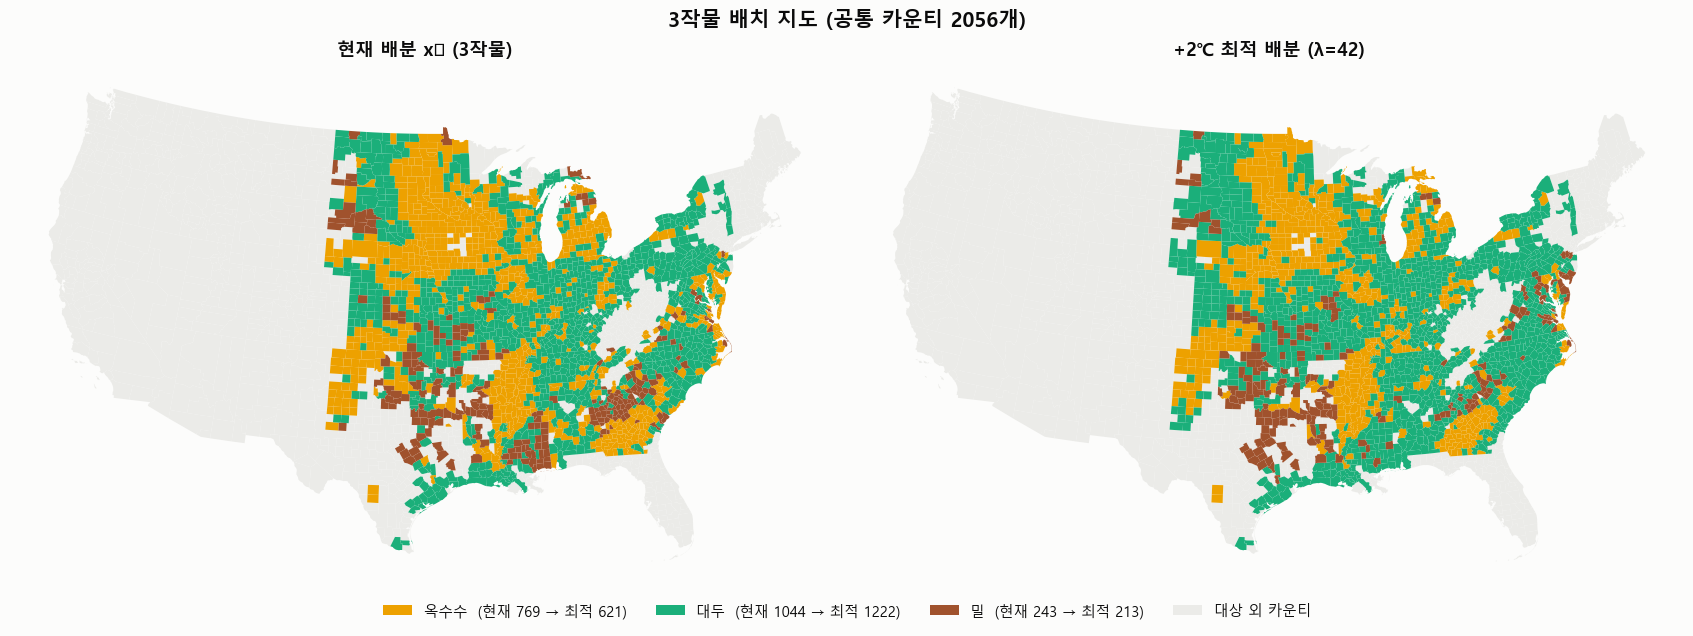


최적해에서 밀을 고른 주 (상위)
       밀_카운티          면적
state                   
TX        31  25666640.0
OK        30  23899575.0
VA        23   4497818.0
MO        18  17874162.0
AR        18   5454322.0
GA        15   1741651.0
KS        15  14989584.0
SC         9   1713582.0
LA         9   2524281.0
NJ         7   1461401.0


In [12]:
import shapefile
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # 읽기 전용
recs, shapes = sf.records(), sf.shapes()
stco_of = [r['stco'] for r in recs]
IDX = {int(s): i for i, s in enumerate(COUNTIES)}

def county_polys(value_of):
    pin, vin, pout = [], [], []
    for i, sh in enumerate(shapes):
        pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
        s = stco_of[i]
        hit = s in value_of
        for a_, b_ in zip(parts[:-1], parts[1:]):
            if hit:
                pin.append(pts[a_:b_]); vin.append(value_of[s])
            else:
                pout.append(pts[a_:b_])
    return pin, np.array(vin), pout

def draw(ax, z, title):
    vo = {int(s): int(z[IDX[int(s)]]) for s in COUNTIES}
    pin, vin, pout = county_polys(vo)
    ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
    for i, k in enumerate(CROPS):
        sel = [p for p, v in zip(pin, vin) if v == i]
        if sel:
            ax.add_collection(PolyCollection(sel, facecolors=CROP_COL[k], edgecolors='none', zorder=2))
    ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.6))
draw(axes[0], XBAR, '현재 배분 x̄ (3작물)')
draw(axes[1], Z_EXACT, '+2℃ 최적 배분 (λ=%.0f)' % KNEE_LAM)
handles = [Patch(facecolor=CROP_COL[k],
                 label='%s  (현재 %d → 최적 %d)'
                       % (CROP_KO[k], int((XBAR == i).sum()), int((Z_EXACT == i).sum())))
           for i, k in enumerate(CROPS)]
handles.append(Patch(facecolor='#ebebe8', label='대상 외 카운티'))
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle('3작물 배치 지도 (공통 카운티 %d개)' % N, fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig45_3crop_map.png'); plt.show()

# 지역별 밀 선택
ST = {1:'AL',5:'AR',8:'CO',9:'CT',10:'DE',12:'FL',13:'GA',17:'IL',18:'IN',19:'IA',20:'KS',
      21:'KY',22:'LA',23:'ME',24:'MD',25:'MA',26:'MI',27:'MN',28:'MS',29:'MO',31:'NE',33:'NH',
      34:'NJ',35:'NM',36:'NY',37:'NC',38:'ND',39:'OH',40:'OK',42:'PA',44:'RI',45:'SC',46:'SD',
      47:'TN',48:'TX',51:'VA',54:'WV',55:'WI',50:'VT',41:'OR',53:'WA',16:'ID',30:'MT',56:'WY'}
g = pd.DataFrame({'stco': COUNTIES, 'state': [ST.get(int(s) // 1000, '??') for s in COUNTIES],
                  'z': Z_EXACT, 'xbar': XBAR, 'A': A})
if (Z_EXACT == 2).any():
    w = g[g.z == 2].groupby('state').agg(밀_카운티=('z', 'size'), 면적=('A', 'sum'))
    w = w.sort_values('밀_카운티', ascending=False)
    print('\n최적해에서 밀을 고른 주 (상위)')
    print(w.head(10).to_string())
else:
    print('\n최적해에서 밀을 고른 카운티가 없다.')

## 9. 결과 저장

In [13]:
out = pd.DataFrame({
    'stco': COUNTIES, 'A_c': A,
    **{'y_hat_%s_base' % k: y_hat[BASE][k] for k in CROPS},
    **{'y_hat_%s_warm' % k: y_hat[WARM][k] for k in CROPS},
    **{'v_%s_base' % k: VAL[BASE][:, i] for i, k in enumerate(CROPS)},
    **{'v_%s_warm' % k: VAL[WARM][:, i] for i, k in enumerate(CROPS)},
    'x_bar': XBAR, 'z_greedy': Z_GREEDY, 'z_exact_knee': Z_EXACT,
    'z_ga': runs['GA']['best'], 'z_sa': runs['SA']['best'], 'z_ts': runs['TS']['best'],
})
out.to_parquet(PROC / 'optimization_3crop_results.parquet', index=False)
print('saved:', PROC / 'optimization_3crop_results.parquet', out.shape)

meta = {
    'purpose': '10 · 3작물(옥수수·대두·밀) 단작 배분 최적화',
    'n_counties': int(N), 'n_crops': 3, 'crops': CROPS,
    'crop_index': {k: i for i, k in enumerate(CROPS)},
    'PRICE_usd_per_bu': PRICE, 'OPCOST_usd_per_ac': OPCOST,
    'lambda_knee': KNEE_LAM, 'seed': SEED,
    'headline': {
        'warming_loss_usd': float(LOSS),
        'recovery_pct_3crop': float(prob.recovery_pct(Z_EXACT, V_WARM_NOADAPT, LOSS)),
        'recovery_pct_2crop_same_counties': float(prob2.recovery_pct(Z2, V2_NOADAPT, LOSS2)),
        'n_wheat_counties': int((Z_EXACT == 2).sum()),
        'wheat_area_pct': float(100 * prob.crop_area(Z_EXACT, 2) / A_TOT),
    },
    'warnings': [
        '밀 모델 학습 연도 1981-2007 → year=2015 예측은 사실상 2007년 기술. 밀이 과소평가된다.',
        '온도 노출 창이 3-8월(MarAug, 옥수수 기준) — 겨울밀의 생육창과 어긋난다.',
        '밀 x_bar 산정도 2011-2015 관측이 없어 전체기간 평균으로 대체됨 (구조적 불리).',
        '밀 가격/변동비는 외부 가정 (USDA ERS 수준).',
        '분리가능성은 K=3 에서도 성립 → 정확해가 O(N·K). 메타휴리스틱은 검증용.',
    ],
}
json.dump(meta, open(PROC / 'optimization_3crop_columns.json', 'w', encoding='utf-8'),
          ensure_ascii=False, indent=2)
print('saved:', PROC / 'optimization_3crop_columns.json')

saved: ..\data\processed\optimization_3crop_results.parquet (2056, 20)


saved: ..\data\processed\optimization_3crop_columns.json


## 10. 요약

In [14]:
rec3 = prob.recovery_pct(Z_EXACT, V_WARM_NOADAPT, LOSS)
rec2 = prob2.recovery_pct(Z2, V2_NOADAPT, LOSS2)

print('=' * 80)
print(' 10 · 3작물 배분 최적화 — 요약'.center(80))
print('=' * 80)
print()
print('[1] 3작물 공통 카운티')
print('    2작물(06) 2,142 → 3작물(10) %d   (밀 추가로 %d개 감소)' % (N, 2142 - N))
print('    탐색 공간 2^2142 → 3^%d' % N)
print()
print('[2] 밀의 위치 (면적가중 순이익, +2℃)')
for i, k in enumerate(CROPS):
    print('    %-4s $%7.1f/ac' % (CROP_KO[k], np.average(VAL[WARM][:, i], weights=A)))
print()
print('[3] 선택지를 늘린 효과 (같은 %d개 카운티, 각자의 무릎)' % N)
print('    2작물  회복률 %.2f%% · 전환 %d 카운티' % (rec2, prob2.n_switched(Z2)))
print('    3작물  회복률 %.2f%% · 전환 %d 카운티' % (rec3, prob.n_switched(Z_EXACT)))
print('    차이   %+.2f%%p' % (rec3 - rec2))
print()
print('[4] 밀이 선택되는가')
nw = int((Z_EXACT == 2).sum())
print('    최적해에서 밀: %d 카운티 (%.1f%%) · 면적 %.2f%%'
      % (nw, 100 * nw / N, 100 * prob.crop_area(Z_EXACT, 2) / A_TOT))
print('    현재 배분 x̄ 의 밀: %d 카운티 (%.1f%%)'
      % (int((XBAR == 2).sum()), 100 * (XBAR == 2).mean()))
print()
print('[5] 문제가 어려워졌는가 (GA·SA·TS, %d seed)' % N_SEEDS)
for _, r in summ3.iterrows():
    print('    %-3s 갭 평균 %.6f%% (최악 %.6f%%) · 정확해 일치 %.2f%% · %.2f초'
          % (r.method, r.갭평균_pct, r.갭최악_pct, r.정확해일치_pct, r.시간_평균초))
if summ3.갭최악_pct.max() < 1e-9:
    print('    → 여전히 셋 다 정확해에 도달.')
else:
    print('    → 처음으로 방법 간 차이가 나타났다 (GA < SA < TS).')
    print('      단, 문제가 어려워진 게 아니라 GA 의 K작물 연산자(random-reset)가 약한 것이다.')
    print('      분리가능성은 K=3 에서도 성립하고, TS 는 정확해에 100%% 도달한다(분산 0).')
print('=' * 80)

                              10 · 3작물 배분 최적화 — 요약                              

[1] 3작물 공통 카운티
    2작물(06) 2,142 → 3작물(10) 2056   (밀 추가로 86개 감소)
    탐색 공간 2^2142 → 3^2056

[2] 밀의 위치 (면적가중 순이익, +2℃)
    옥수수  $  160.7/ac
    대두   $  186.6/ac
    밀    $  114.9/ac

[3] 선택지를 늘린 효과 (같은 2056개 카운티, 각자의 무릎)
    2작물  회복률 15.99% · 전환 233 카운티
    3작물  회복률 19.12% · 전환 333 카운티
    차이   +3.13%p

[4] 밀이 선택되는가
    최적해에서 밀: 213 카운티 (10.4%) · 면적 7.64%
    현재 배분 x̄ 의 밀: 243 카운티 (11.8%)

[5] 문제가 어려워졌는가 (GA·SA·TS, 10 seed)
    GA  갭 평균 0.010370% (최악 0.016151%) · 정확해 일치 98.35% · 8.18초
    SA  갭 평균 0.000003% (최악 0.000021%) · 정확해 일치 99.98% · 1.06초
    TS  갭 평균 0.000000% (최악 0.000000%) · 정확해 일치 100.00% · 0.18초
    → 처음으로 방법 간 차이가 나타났다 (GA < SA < TS).
      단, 문제가 어려워진 게 아니라 GA 의 K작물 연산자(random-reset)가 약한 것이다.
      분리가능성은 K=3 에서도 성립하고, TS 는 정확해에 100%% 도달한다(분산 0).


## 11. 이상한 점 · 한계

**1. 밀은 구조적으로 불리하게 평가된다 — 세 겹의 페널티**
- (a) **year 클램핑**: 밀 모델은 1981–2007 학습. `year=2015` 예측 시 트리가 외삽하지 못해
  **2007년 기술 수준**을 반환한다. 옥수수·대두는 2015년 기술로 예측된다(04c §5).
- (b) **x̄ 산정**: 현재 배분 규칙이 "2011–2015 관측 수확량"인데, 밀은 그 기간 관측이 **0건**이다.
  전체 기간(1981–2007) 평균으로 대체되므로 역시 낡은 값이 쓰인다.
- (c) **생육창 불일치**: 온도 노출이 3–8월(옥수수 기준)이다. 겨울밀의 실제 생육창과 어긋난다.

즉 **"밀이 선택되지 않았다"는 결과를 "밀이 나쁘다"로 읽으면 안 된다.** 세 겹의 핸디캡을
안고도 밀이 선택되는 카운티가 있다면, 그건 오히려 강한 신호다.

**2. 2작물 vs 3작물 비교의 함정**
06은 2,142개, 10은 그보다 적은 카운티에서 정의된다. 카운티 집합이 다르면 회복률을 직접
비교할 수 없다. 그래서 §7에서 **같은 카운티 집합 위에서** 2작물 문제를 다시 풀어 비교했다.
발표에서 06의 15.99%와 10의 회복률을 나란히 놓으면 **틀린 비교**가 된다.

**3. 선택지를 늘리면 회복률은 반드시 (약)증가한다 — 이건 검증이지 발견이 아니다**
3작물 최적해는 2작물 해를 포함하는 더 큰 집합에서 고른 것이므로, 수학적으로 회복률이
**떨어질 수 없다.** 따라서 "3작물이 더 좋다"는 결과 자체는 놀랍지 않다.
의미 있는 질문은 **"얼마나 더 좋아지는가"** 와 **"밀이 실제로 쓰이는가"** 다.

**4. ★ K=3 에서 처음으로 방법 간 차이가 났다 — 하지만 해석에 주의**
06~09의 2작물 문제에서는 GA·SA·TS가 **전부** 정확해에 도달했다. K=3 에서는 갈렸다:
TS 갭 0.000000%(일치 100%, 분산 0) > SA 0.000003% > **GA 0.010%(일치 98.3%)**.

**이것을 "K=3 이라 문제가 어려워졌다"로 읽으면 틀린다.** 문제는 여전히 분리 가능하고,
정확해는 O(N·K) 에 나온다. 달라진 것은 **GA의 연산자**다:
- 이진에서 bit-flip 은 "뒤집기" 한 가지 → 항상 유일한 대안으로 간다.
- K작물의 random-reset 은 K−1 개 중 **무작위로** 하나를 고른다 → 탐색이 묽어진다.

즉 정확한 서술은 **"GA가 K작물에서 약해졌다"** 이지 "문제가 어려워졌다"가 아니다.
(더 나은 K작물 GA 연산자 — 예: 유망한 작물로 편향된 reset — 를 쓰면 격차가 줄 것이다.)

**5. 분리가능성은 K에 무관하게 성립한다**
목적함수에 카운티 간 항이 없으므로, K=3 이어도 per-county argmax 가 정확해다.
따라서 **K를 늘려도 문제가 "어려워지지" 않는다.** 탐색 공간이 3^2056 으로 커지는 것은
사실이지만, 그건 무차별 대입에만 해당한다. 메타휴리스틱이 의미를 가지려면
**카운티를 서로 묶는 제약**(최소 수요, 인접 제약 등)이 필요하다 — 06 §7, 08 §6과 같은 결론이다.

**6. 밀 가격·변동비도 외부 가정이다**
$6.50/bu · $175/ac 를 썼다(USDA ERS 수준). 옥수수·대두와 마찬가지로 데이터에 없는 값이며,
이 숫자가 밀의 선택 여부를 좌우한다. 발표 전 출처 확정과 민감도 분석이 필요하다.

**7. 06~09의 결론은 그대로다**
이 노트북은 확장일 뿐 06~09를 바꾸지 않았다.